<a href="https://colab.research.google.com/github/Cpea8713/Lab1/blob/main/assignment_06_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [ ]:
# Import standard libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# Load your uploaded file (path "/content/listings.csv.gz") 🔧
df = pd.read_csv('/content/listings.csv.gz', compression='gzip')
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,164448,https://www.airbnb.com/rooms/164448,20260925011206,2026-09-27,NaN,Double room in central Stockholm with Wi-Fi,I am renting out a nice double room on the top...,NaN,https://a0.muscache.com/pictures/f56d8d10-a7fa...,784312,...,4.97,4.85,4.75,NaN,NaN,2,0,2,0,2.62
1,220851,https://www.airbnb.com/rooms/220851,20260925011206,2026-09-27,NaN,One room in appartement,Welcome!,NaN,https://a0.muscache.com/pictures/2085606/7a706...,412283,...,4.88,4.82,4.72,NaN,NaN,2,1,1,0,0.37
2,242188,https://www.airbnb.com/rooms/242188,20260925011206,2026-09-27,NaN,Single room in central Stockholm with Wi-Fi,I am renting out a nice single room on the top...,NaN,https://a0.muscache.com/pictures/2303148/55d1e...,784312,...,4.98,4.89,4.83,NaN,NaN,2,0,2,0,2.67
3,273906,https://www.airbnb.com/rooms/273906,20260925011206,2026-09-26,NaN,Penthouse in central Stockholm,<b>The space</b><br />This is a unique penthou...,NaN,https://a0.muscache.com/pictures/2881091/f5404...,1432722,...,4.75,5.00,5.00,NaN,NaN,2,2,0,0,0.02
4,299863,https://www.airbnb.com/rooms/299863,20260925011206,2026-09-27,NaN,Playful temple with genuine meetings for big&s...,You are welcome to the big and bright room in ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,1322033,...,4.65,4.40,4.43,NaN,NaN,1,1,0,0,0.54


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

Missing Values by Column:
id                                                 0
listing_url                                        0
scrape_id                                          0
last_scraped                                       0
source                                          2870
                                                ... 
calculated_host_listings_count                     0
calculated_host_listings_count_entire_homes        0
calculated_host_listings_count_private_rooms       0
calculated_host_listings_count_shared_rooms        0
reviews_per_month                                644
Length: 90, dtype: int64

Percentage of Missing Values:
neighborhood_overview                           100.0
host_since                                      100.0
host_response_time                              100.0
host_thumbnail_url                              100.0
host_acceptance_rate                            100.0
                                                ...  
availabilit

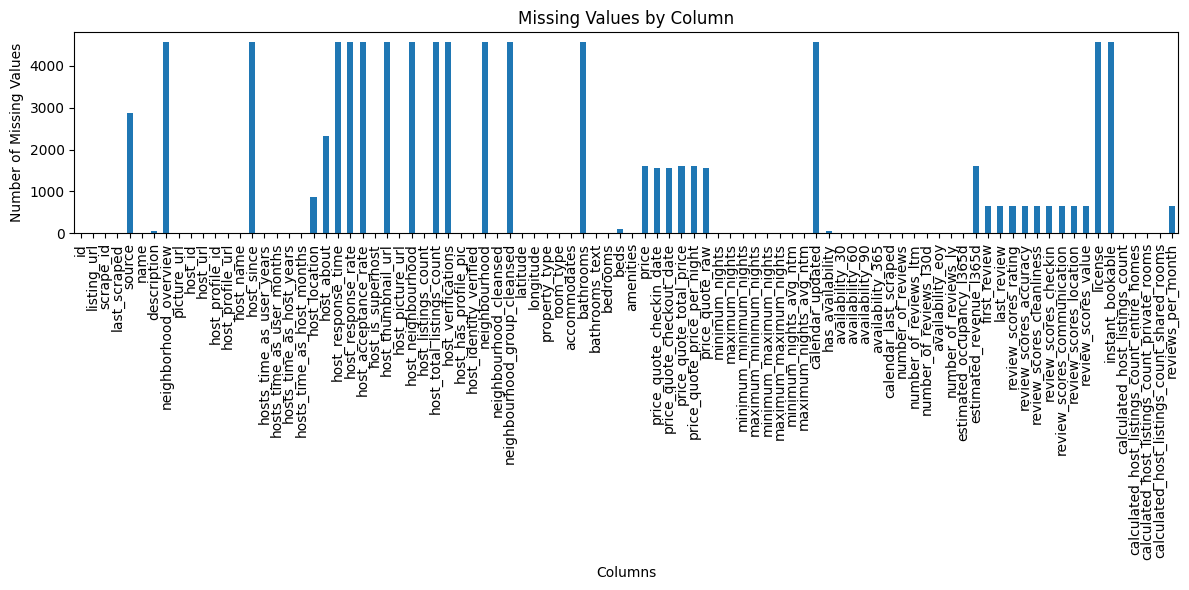

In [ ]:
import matplotlib.pyplot as plt
missing_values = df.isnull().sum()
print("Missing Values by Column:")
print(missing_values)
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of Missing Values:")
print(missing_percent.sort_values(ascending=False))
plt.figure(figsize=(12, 6))
missing_values.plot(kind='bar')
plt.title('Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧
1. Five columns are tied with 100% missing data, including neighborhood_overview, host_since, and host_response_time.

2. Missing information about hosts, such as host_response_time and host_acceptance_rate, could make it harder to evaluate how reliable hosts are. Missing neighborhood information could also make it harder to understand what makes certain locations more desirable.

3. Columns like host_thumbnail_url and host_picture_url could be dropped because they don't provide much value for analyzing Airbnb prices or booking trends. Columns with 100% missing values should also be considered for removal because they don't provide usable information.


## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [ ]:
# Add code here 🔧
columns_to_drop = ['neighborhood_overview','host_since','host_response_time','host_thumbnail_url']
df = df.drop(columns=columns_to_drop)
print("Columns remaining:", len(df.columns))
print("\nRemaining columns:")
print(df.columns.tolist())
display(df.head())

Columns remaining: 86

Remaining columns:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw', 'minimum_nights', 'maximum_nights', 'minimum_minimum_

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,164448,https://www.airbnb.com/rooms/164448,20260925011206,2026-09-27,NaN,Double room in central Stockholm with Wi-Fi,I am renting out a nice double room on the top...,https://a0.muscache.com/pictures/f56d8d10-a7fa...,784312,https://www.airbnb.com/users/show/784312,...,4.97,4.85,4.75,NaN,NaN,2,0,2,0,2.62
1,220851,https://www.airbnb.com/rooms/220851,20260925011206,2026-09-27,NaN,One room in appartement,Welcome!,https://a0.muscache.com/pictures/2085606/7a706...,412283,https://www.airbnb.com/users/show/412283,...,4.88,4.82,4.72,NaN,NaN,2,1,1,0,0.37
2,242188,https://www.airbnb.com/rooms/242188,20260925011206,2026-09-27,NaN,Single room in central Stockholm with Wi-Fi,I am renting out a nice single room on the top...,https://a0.muscache.com/pictures/2303148/55d1e...,784312,https://www.airbnb.com/users/show/784312,...,4.98,4.89,4.83,NaN,NaN,2,0,2,0,2.67
3,273906,https://www.airbnb.com/rooms/273906,20260925011206,2026-09-26,NaN,Penthouse in central Stockholm,<b>The space</b><br />This is a unique penthou...,https://a0.muscache.com/pictures/2881091/f5404...,1432722,https://www.airbnb.com/users/show/1432722,...,4.75,5.00,5.00,NaN,NaN,2,2,0,0,0.02
4,299863,https://www.airbnb.com/rooms/299863,20260925011206,2026-09-27,NaN,Playful temple with genuine meetings for big&s...,You are welcome to the big and bright room in ...,https://a0.muscache.com/pictures/hosting/Hosti...,1322033,https://www.airbnb.com/users/show/1322033,...,4.65,4.40,4.43,NaN,NaN,1,1,0,0,0.54


### Reflection:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response: 🔧
1. I dropped four columns: neighborhood_overview, host_since, host_response_time, and host_thumbnail_url.

2. All four columns had 100% missing values, so they weren't providing any useful information. Keeping them wouldn't help us understand Airbnb pricing, host performance, or customer preferences.

3. Leaving these columns would make the dataset more complicated than necessary and could cause issues when creating charts or building models to make business decisions.



## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [ ]:
# Your code for converting column data types 🔧
print("Missing values before:")
print(df[['review_scores_rating', 'license']].isnull().sum())
median_rating = df['review_scores_rating'].median()
df['review_scores_rating'] = df['review_scores_rating'].fillna(median_rating)
df['license'] = df['license'].fillna('Unknown')
print("\nMissing values after:")
print(df[['review_scores_rating', 'license']].isnull().sum())
display(df[['review_scores_rating', 'license']].head())

Missing values before:
review_scores_rating       0
license                 4574
dtype: int64

Missing values after:
review_scores_rating    0
license                 0
dtype: int64


,review_scores_rating,license
0,4.86,Unknown
1,4.70,Unknown
2,4.90,Unknown
3,5.00,Unknown
4,4.36,Unknown


### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response: 🔧
1. I cleaned the review_scores_rating and license columns.

2. For review scores, I filled the 644 missing values using the median because it represents a typical rating without being heavily affected by extreme values. For licenses, I replaced the 4,574 missing values with "Unknown" because I didn't want to assume those properties were unlicensed.

3. Filling missing review scores with the median could make the ratings look more consistent than they actually are and affect our analysis. Using "Unknown" for licenses also means we still don't know whether those properties are licensed, which could limit our ability to evaluate compliance.


## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

Original price data type:
object

New price data type:
float64

Price Summary:
count     2957.000000
mean      2327.643382
std       2160.353619
min        120.000000
25%       1071.120000
50%       1791.000000
75%       3003.800000
max      40000.000000
Name: price, dtype: float64


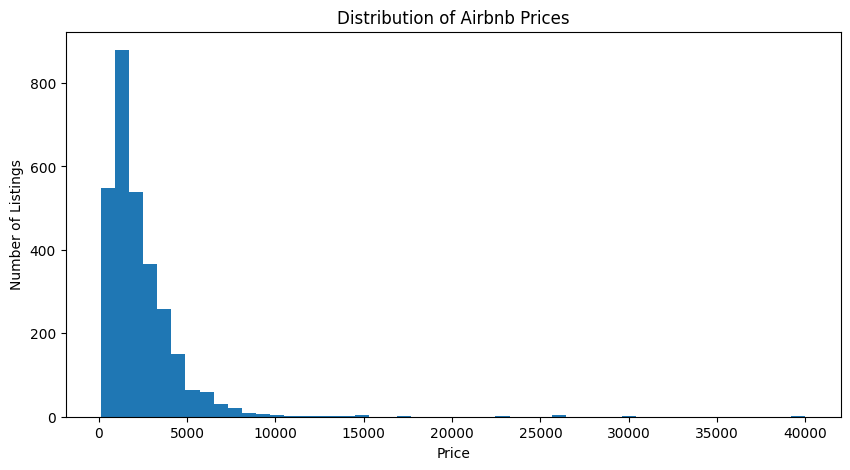

In [ ]:
# Clean or adjust your dataset 🔧

print("Original price data type:")
print(df['price'].dtype)

df['price'] = pd.to_numeric(df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False),errors='coerce')

print("\nNew price data type:")
print(df['price'].dtype)

print("\nPrice Summary:")
print(df['price'].describe())

plt.figure(figsize=(10, 5))
plt.hist(df['price'].dropna(), bins=50)
plt.title('Distribution of Airbnb Prices')
plt.xlabel('Price')
plt.ylabel('Number of Listings')
plt.show()

### Reflection: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response: 🔧
1. I fixed the price column in my Airbnb dataset because the prices were stored as text instead of numbers.

2. I removed currency symbols and commas from the prices and converted the column into numeric values. I then created a histogram and calculated summary statistics to make sure the conversion worked correctly.

3. Converting prices into numbers allows us to calculate averages, compare listing prices, and create accurate charts. This will help us identify pricing trends and make better business decisions based on the data.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

In [ ]:
# Add code here 🔧
print("Exact duplicate rows:", df.duplicated().sum())

print("Duplicate listing IDs:", df['id'].duplicated().sum())

df = df.drop_duplicates()

df = df.drop_duplicates(subset=['id'], keep='first')

print("\nAfter cleaning:")
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate listing IDs:", df['id'].duplicated().sum())

print("\nDataset shape:", df.shape)

display(df.head())

Exact duplicate rows: 0
Duplicate listing IDs: 0

After cleaning:
Exact duplicate rows: 0
Duplicate listing IDs: 0

Dataset shape: (4574, 86)


,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,164448,https://www.airbnb.com/rooms/164448,20260925011206,2026-09-27,NaN,Double room in central Stockholm with Wi-Fi,I am renting out a nice double room on the top...,https://a0.muscache.com/pictures/f56d8d10-a7fa...,784312,https://www.airbnb.com/users/show/784312,...,4.97,4.85,4.75,Unknown,NaN,2,0,2,0,2.62
1,220851,https://www.airbnb.com/rooms/220851,20260925011206,2026-09-27,NaN,One room in appartement,Welcome!,https://a0.muscache.com/pictures/2085606/7a706...,412283,https://www.airbnb.com/users/show/412283,...,4.88,4.82,4.72,Unknown,NaN,2,1,1,0,0.37
2,242188,https://www.airbnb.com/rooms/242188,20260925011206,2026-09-27,NaN,Single room in central Stockholm with Wi-Fi,I am renting out a nice single room on the top...,https://a0.muscache.com/pictures/2303148/55d1e...,784312,https://www.airbnb.com/users/show/784312,...,4.98,4.89,4.83,Unknown,NaN,2,0,2,0,2.67
3,273906,https://www.airbnb.com/rooms/273906,20260925011206,2026-09-26,NaN,Penthouse in central Stockholm,<b>The space</b><br />This is a unique penthou...,https://a0.muscache.com/pictures/2881091/f5404...,1432722,https://www.airbnb.com/users/show/1432722,...,4.75,5.00,5.00,Unknown,NaN,2,2,0,0,0.02
4,299863,https://www.airbnb.com/rooms/299863,20260925011206,2026-09-27,NaN,Playful temple with genuine meetings for big&s...,You are welcome to the big and bright room in ...,https://a0.muscache.com/pictures/hosting/Hosti...,1322033,https://www.airbnb.com/users/show/1322033,...,4.65,4.40,4.43,Unknown,NaN,1,1,0,0,0.54


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response: 🔧 🔧
1.  No, I checked for both exact duplicate rows and duplicate listing IDs, and there were zero duplicates in the dataset.

2. I checked whether any rows were identical or had the same listing ID. Since there were no duplicates, I kept all 4,574 listings because there was no reason to remove any.

3. Duplicates could cause listings to be counted more than once, making the data inaccurate. This could lead to incorrect pricing averages, inflated listing counts, and poor business decisions based on misleading information.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [ ]:
# export csv here 🔧

df.to_csv('cleaned_airbnb_data_6.csv', index=False)

print("Cleaned Airbnb dataset exported successfully!")
print("Dataset shape:", df.shape)

Cleaned Airbnb dataset exported successfully!
Dataset shape: (4574, 86)


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information)
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. The most challenging part for me was deciding how to handle missing values. The coding wasn't too difficult, but understanding which data should be removed and which should be filled required more thought. I had to consider how those decisions could affect the accuracy of the analysis.
2. One example was when I removed four columns that had 100% missing values. Since those columns didn't contain any useful information, keeping them would only make the dataset more complicated. Removing them helped simplify the data without losing anything valuable.
3. Airbnb pricing analysts could use the cleaned dataset to compare listing prices and identify pricing trends. Having more consistent data would help them make better recommendations about how much hosts should charge for their properties.
4. If I had more time, I would look further into the unusually high listing prices that showed up in the histogram. Some properties were priced significantly higher than others, and I would want to understand whether those prices were accurate or outliers that could affect the analysis.
5. My customized learning outcome focuses on using data to make better decisions in real estate, especially when evaluating property values and potential returns on investments. This assignment relates to that because cleaning data is an important step before using it to compare properties or build models. If the data isn't accurate, the decisions based on it might not be accurate either.


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"

[NbConvertApp] Converting notebook assignment_06_data_cleaning.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 598800 bytes to assignment_06_data_cleaning.html
